# Wariacyjny autoenkoder domowej roboty

In [1]:
!pip install minisom matplotlib

In [2]:
import numpy as np
from minisom import MiniSom
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# Download MNIST dataset
X_mnist, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
# Normalize data
X_mnist = X_mnist / 255.0


In [3]:
X_mnist = X_mnist[y == '9']
X_mnist.shape

(6958, 784)

# miniSOM

In [4]:
def plot_som_centroids(som, som_size):
    # Plot the weights of the Kohonen map
    plt.figure(figsize=(som_size, som_size))
    for i in range(som_size):
        for j in range(som_size):
            weight = som.get_weights()[i, j].reshape(28, 28)  # Reshape weights to 28x28 (MNIST images size)
            plt.subplot(som_size, som_size, i*som_size+j+1)
            plt.imshow(weight, cmap='gray')
            plt.axis('off')
    plt.show()

In [5]:
# Initialize Kohonen map (SOM)
som_size = 20  # 10x10 grid
som = MiniSom(som_size, som_size, X_mnist.shape[1], sigma=1.0, learning_rate=0.5)

# Train SOM

In [6]:
print("Training Kohonen map...")

for epoch in range(10):
    print(f"Epoch {epoch+1}/10, Quantization error:, {som.quantization_error(X_mnist)}", end=" ")

    som.train_random(X_mnist, X_mnist.shape[0])  # Train with 60000 iterations
    print()

print("Training completed.")

Training Kohonen map...
Epoch 1/10, Quantization error:, 8.910734873297388 
Epoch 2/10, Quantization error:, 4.003898394090621 
Epoch 3/10, Quantization error:, 3.877462148040334 
Epoch 4/10, Quantization error:, 3.8389270842304555 
Epoch 5/10, Quantization error:, 3.827983915014106 
Epoch 6/10, Quantization error:, 3.826898599266215 
Epoch 7/10, Quantization error:, 3.8302399680156234 
Epoch 8/10, Quantization error:, 3.8251454978309263 
Epoch 9/10, Quantization error:, 3.8240914386100613 
Epoch 10/10, Quantization error:, 3.8192358770921335 
Training completed.


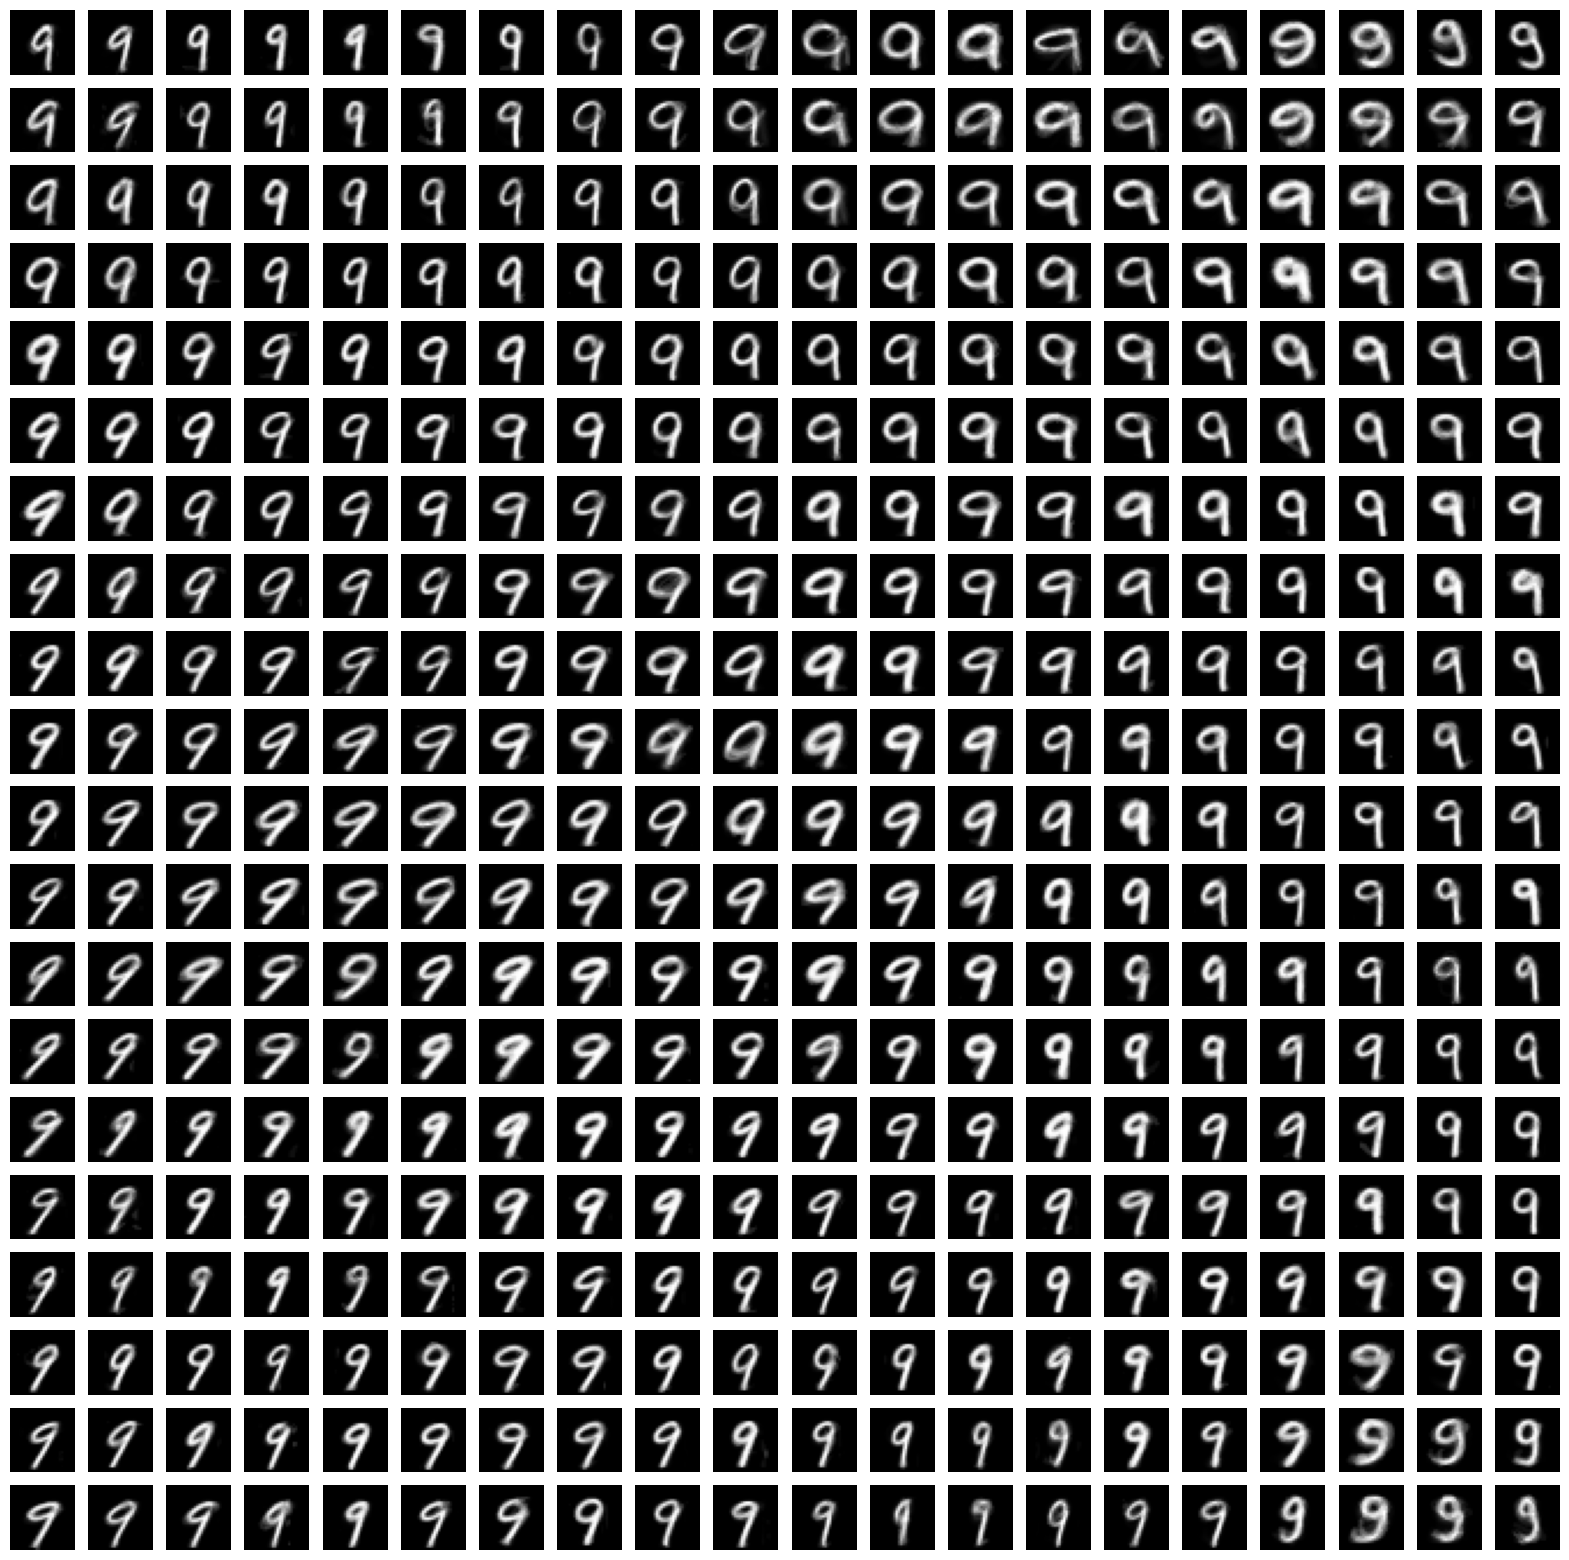

In [7]:
plot_som_centroids(som, som_size)


# learning inverse function

In [8]:
from sklearn.neighbors import NearestNeighbors

def round_centroids(som, som_size, X_mnist):
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(X_mnist)

    round_centroids = np.zeros((som_size, som_size, 28, 28))
    for i in range(som_size):
        for j in range(som_size):
            centroid = som.get_weights()[i, j].reshape(1, -1)
            _, idx = nn.kneighbors(centroid, 1)
            
            round_centroids[i,j] = X_mnist[idx,:].reshape(28,28)
    return round_centroids

rounded_centroids = round_centroids(som, som_size, X_mnist)

Poniżej: $X \in \mathbb{R}^2$, natomiast $Y\in \mathbb{R}^{784}$. $x_i$ to pozycja $i$-tego centroidu w topologii mapy Kohonena, natomiast $y_i$ to nie jest sama surowa pozycja tego centroidu w $\mathbb{R}^{784}$, tylko $y_i$ to jest najbliższy centroidowi prawdziwy obrazek. Dzięki temu model uczy się na obrazkach z ostrzejszym detalem.

In [9]:
X_latent = np.zeros((som_size**2, 2))
Y = np.zeros((som_size**2, 784))

for i in range(som_size):
    for j in range(som_size):
        X_latent[i*som_size+j,:] = np.array([i, j])
        Y[i*som_size+j,:] = rounded_centroids[i,j].reshape(1, -1)

In [10]:
!pip install xgboost

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# 1. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_latent, Y, test_size=0.2, random_state=42
)

# 2. Define XGBRegressor with verbosity and error checking
model = XGBRegressor(
    max_depth=9,
    n_estimators=200,
    learning_rate=0.9,
    verbosity=1,                # More verbose output (0 = silent, 1 = warning, 2 = info, 3 = debug)
    eval_metric='rmse',         # Can be 'rmse', 'mae', etc.
    objective='reg:squarederror'
)

# 3. Fit with eval_set for verbose validation error output
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True
)

# 4. Predict and print error metrics
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("\nTrain RMSE:", mean_squared_error(y_train, y_pred_train, squared=False))
print("Test RMSE:", mean_squared_error(y_test, y_pred_test, squared=False))
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))


[0]	validation_0-rmse:0.11258	validation_1-rmse:0.18558
[1]	validation_0-rmse:0.06664	validation_1-rmse:0.18364
[2]	validation_0-rmse:0.04755	validation_1-rmse:0.18750
[3]	validation_0-rmse:0.03528	validation_1-rmse:0.19029
[4]	validation_0-rmse:0.02646	validation_1-rmse:0.19225
[5]	validation_0-rmse:0.02016	validation_1-rmse:0.19362
[6]	validation_0-rmse:0.01530	validation_1-rmse:0.19455
[7]	validation_0-rmse:0.01164	validation_1-rmse:0.19521
[8]	validation_0-rmse:0.00895	validation_1-rmse:0.19569
[9]	validation_0-rmse:0.00690	validation_1-rmse:0.19602
[10]	validation_0-rmse:0.00531	validation_1-rmse:0.19626
[11]	validation_0-rmse:0.00415	validation_1-rmse:0.19643
[12]	validation_0-rmse:0.00329	validation_1-rmse:0.19654
[13]	validation_0-rmse:0.00266	validation_1-rmse:0.19663
[14]	validation_0-rmse:0.00220	validation_1-rmse:0.19668
[15]	validation_0-rmse:0.00196	validation_1-rmse:0.19671
[16]	validation_0-rmse:0.00181	validation_1-rmse:0.19673
[17]	validation_0-rmse:0.00175	validation

In [12]:
X_latent.shape

(400, 2)

In [13]:
def plot_grid_numbers(model, rounded_centroids):
    som_size = rounded_centroids.shape[0]
    plt.figure(figsize=(som_size, som_size))
    for i in range(som_size):
        for j in range(som_size):
            x = np.array([[i, j]]) + np.random.uniform(low=-0.5, high=0.5, size=(2))           
            plt.subplot(som_size, som_size, i*som_size+j+1)
            plt.imshow(model.predict(x).reshape(28,28), cmap='gray')
            plt.axis('off')
    plt.show()

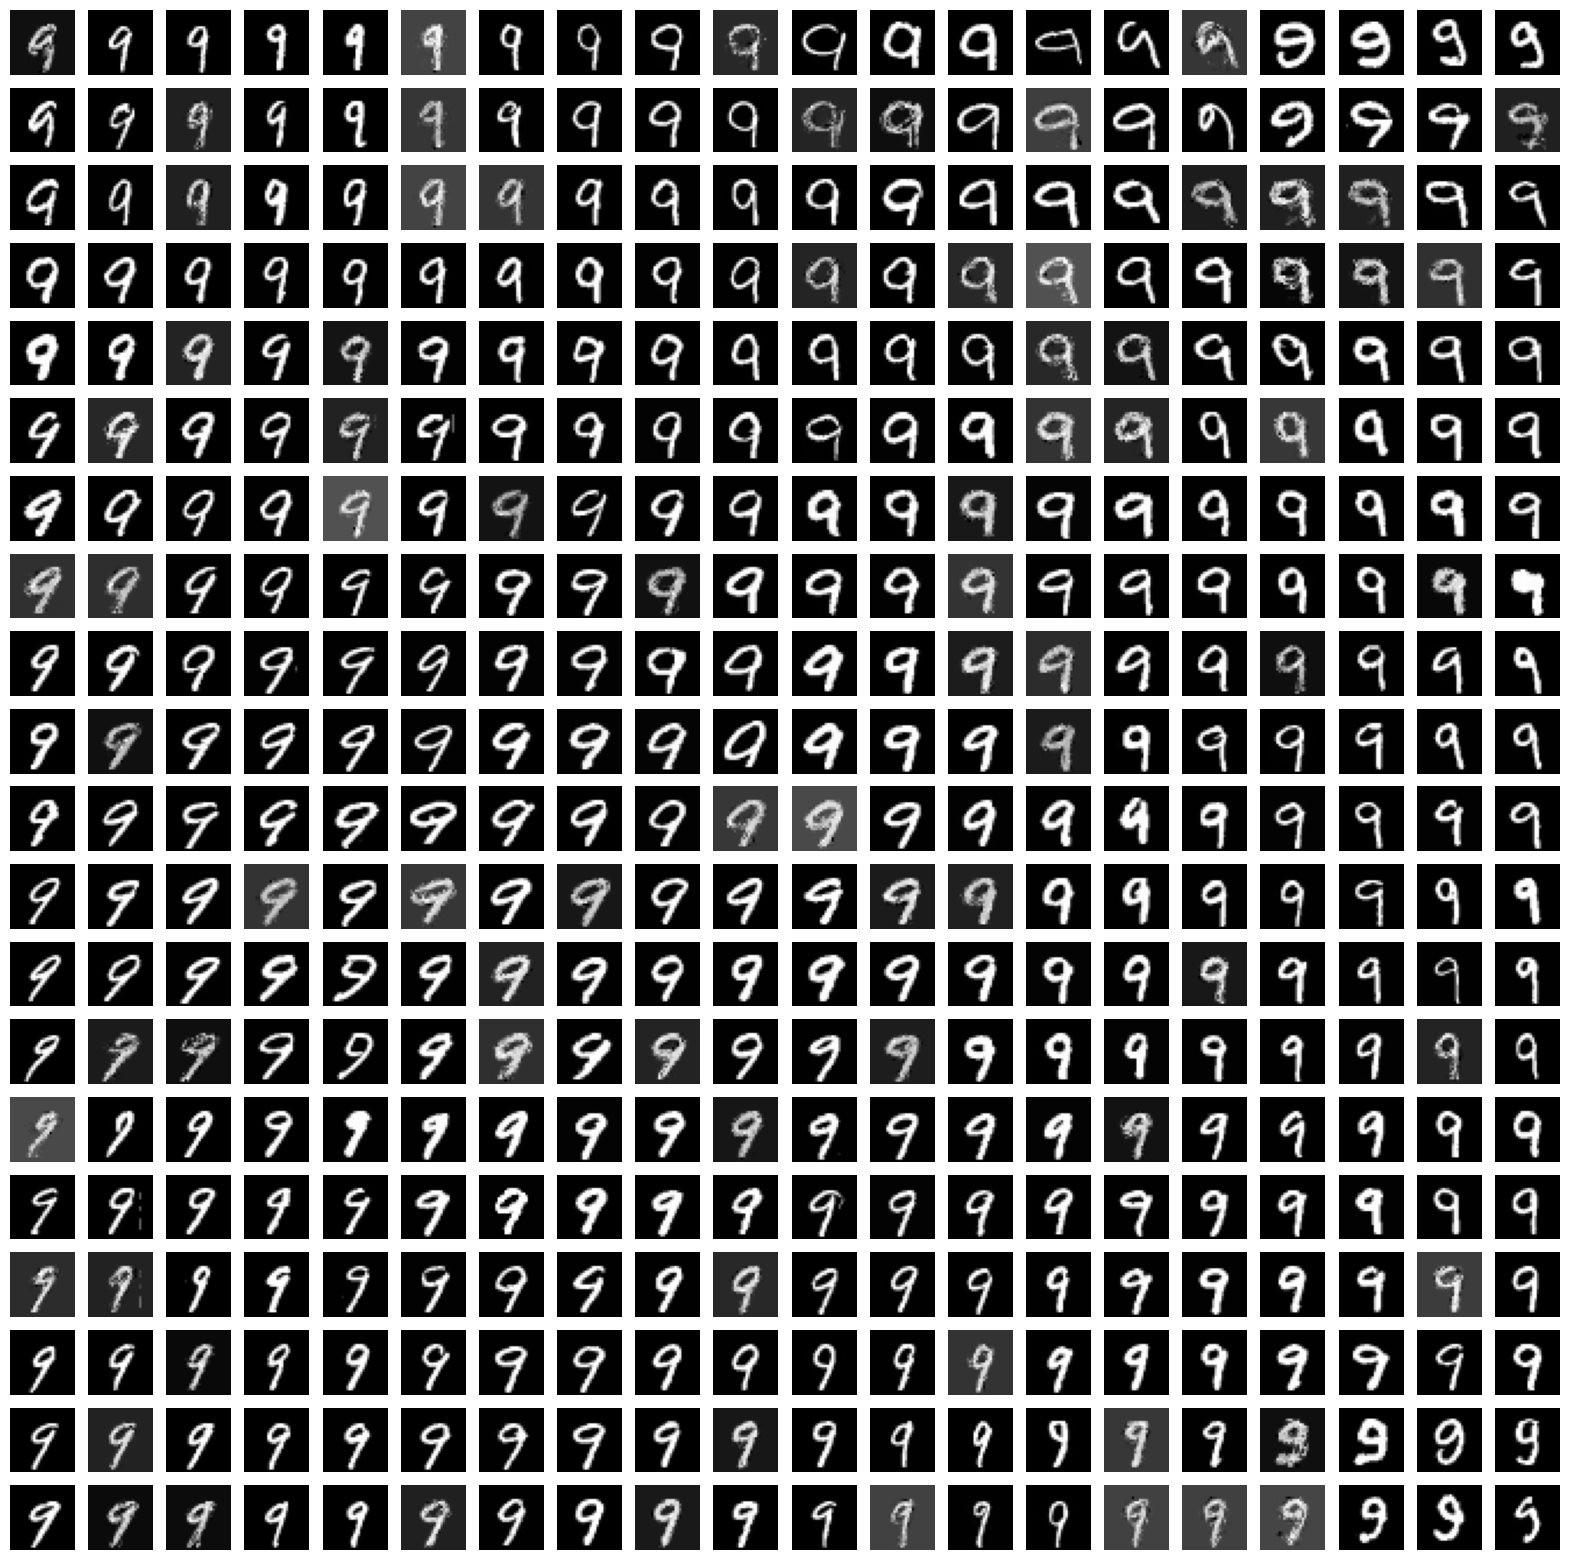

In [14]:
plot_grid_numbers(model, rounded_centroids)

# jak ocenić jakość generacji?

Użyjmy kolejnego klasyfikatora do oceny jakości generowania. Stwórzmy dataset złożony z oryginalnych obrazków i złożony z takiej samej ilości obrazków wygenerowanych przez nas. Labele y mówią 1, gdy prawdziwy, a 0, gdy fejk.
Intuicja:
- jeśli obrazki są słabe, to k-NN będzie miał 100% accuracy przy klasyfikacji
- jeśli obrazki są idealnie wierne oryginałom, to accuracy będzie bardzo niskie

Zadanie do pomyślenia:
- **czy w ogóle możliwe jest, aby 1-NN klasyfikator mógł mieć kiedykolwiek 0% accuracy? co dla 2-NN?**

In [15]:
X_tru = Y
X_tru.shape

(400, 784)

In [16]:
data_uniform = np.random.uniform(0, 19, (X_tru.shape[0], 2))
data_uniform

array([[ 6.39305723, 13.13888696],
       [ 1.51699101,  3.31866162],
       [17.37444721, 17.5280214 ],
       [15.29020341,  1.90522923],
       [ 6.48752398, 10.36027102],
       [ 4.85782805, 10.44810393],
       [12.36397742,  3.60869128],
       [10.75255231,  3.88602812],
       [ 6.85436155, 12.64041312],
       [13.58918187,  9.35513546],
       [10.22436935, 10.86404381],
       [ 5.03821077,  7.88768881],
       [ 0.07488135,  4.28704971],
       [15.67832742, 18.50161004],
       [11.88497312, 18.91695742],
       [16.32052797, 10.97458709],
       [15.42491431,  0.72161667],
       [18.84161261, 18.47756713],
       [15.24383453, 10.94997555],
       [ 7.62526399, 14.97164228],
       [18.92889676, 12.26933589],
       [ 2.29395628,  2.53505164],
       [ 5.11701225, 12.7483002 ],
       [ 2.14451493, 16.601954  ],
       [ 8.17021063,  0.80807968],
       [16.94394541, 10.31345334],
       [ 3.99324672,  6.64938348],
       [ 8.18122579, 11.60084935],
       [11.89534971,

In [17]:
data_uniform.shape

(400, 2)

In [18]:
generated_images = []
for i, random_point in enumerate(data_uniform):
    generated_images.append(model.predict(random_point.reshape(1, -1)).reshape(-1))

X_gen = np.array(generated_images)

In [19]:
X_gen.shape

(400, 784)

In [20]:
X = np.vstack([X_tru, X_gen])
y = np.array(X_tru.shape[0]*[1] + X_gen.shape[0]*[0])

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Split the dataset into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create kNN classifier. You can adjust the number of neighbors (n_neighbors)
knn = KNeighborsClassifier(n_neighbors=3)

# Train the classifier
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 45.42%


In [22]:
def plot_generated_images(generated_images):
    plt.figure(figsize=(som_size, som_size))
    for i in range(som_size):
        for j in range(som_size):           
            plt.subplot(som_size, som_size, i*som_size+j+1)
            plt.imshow(generated_images[i*som_size + j].reshape(28,28), cmap='gray')
            plt.axis('off')
    plt.show()

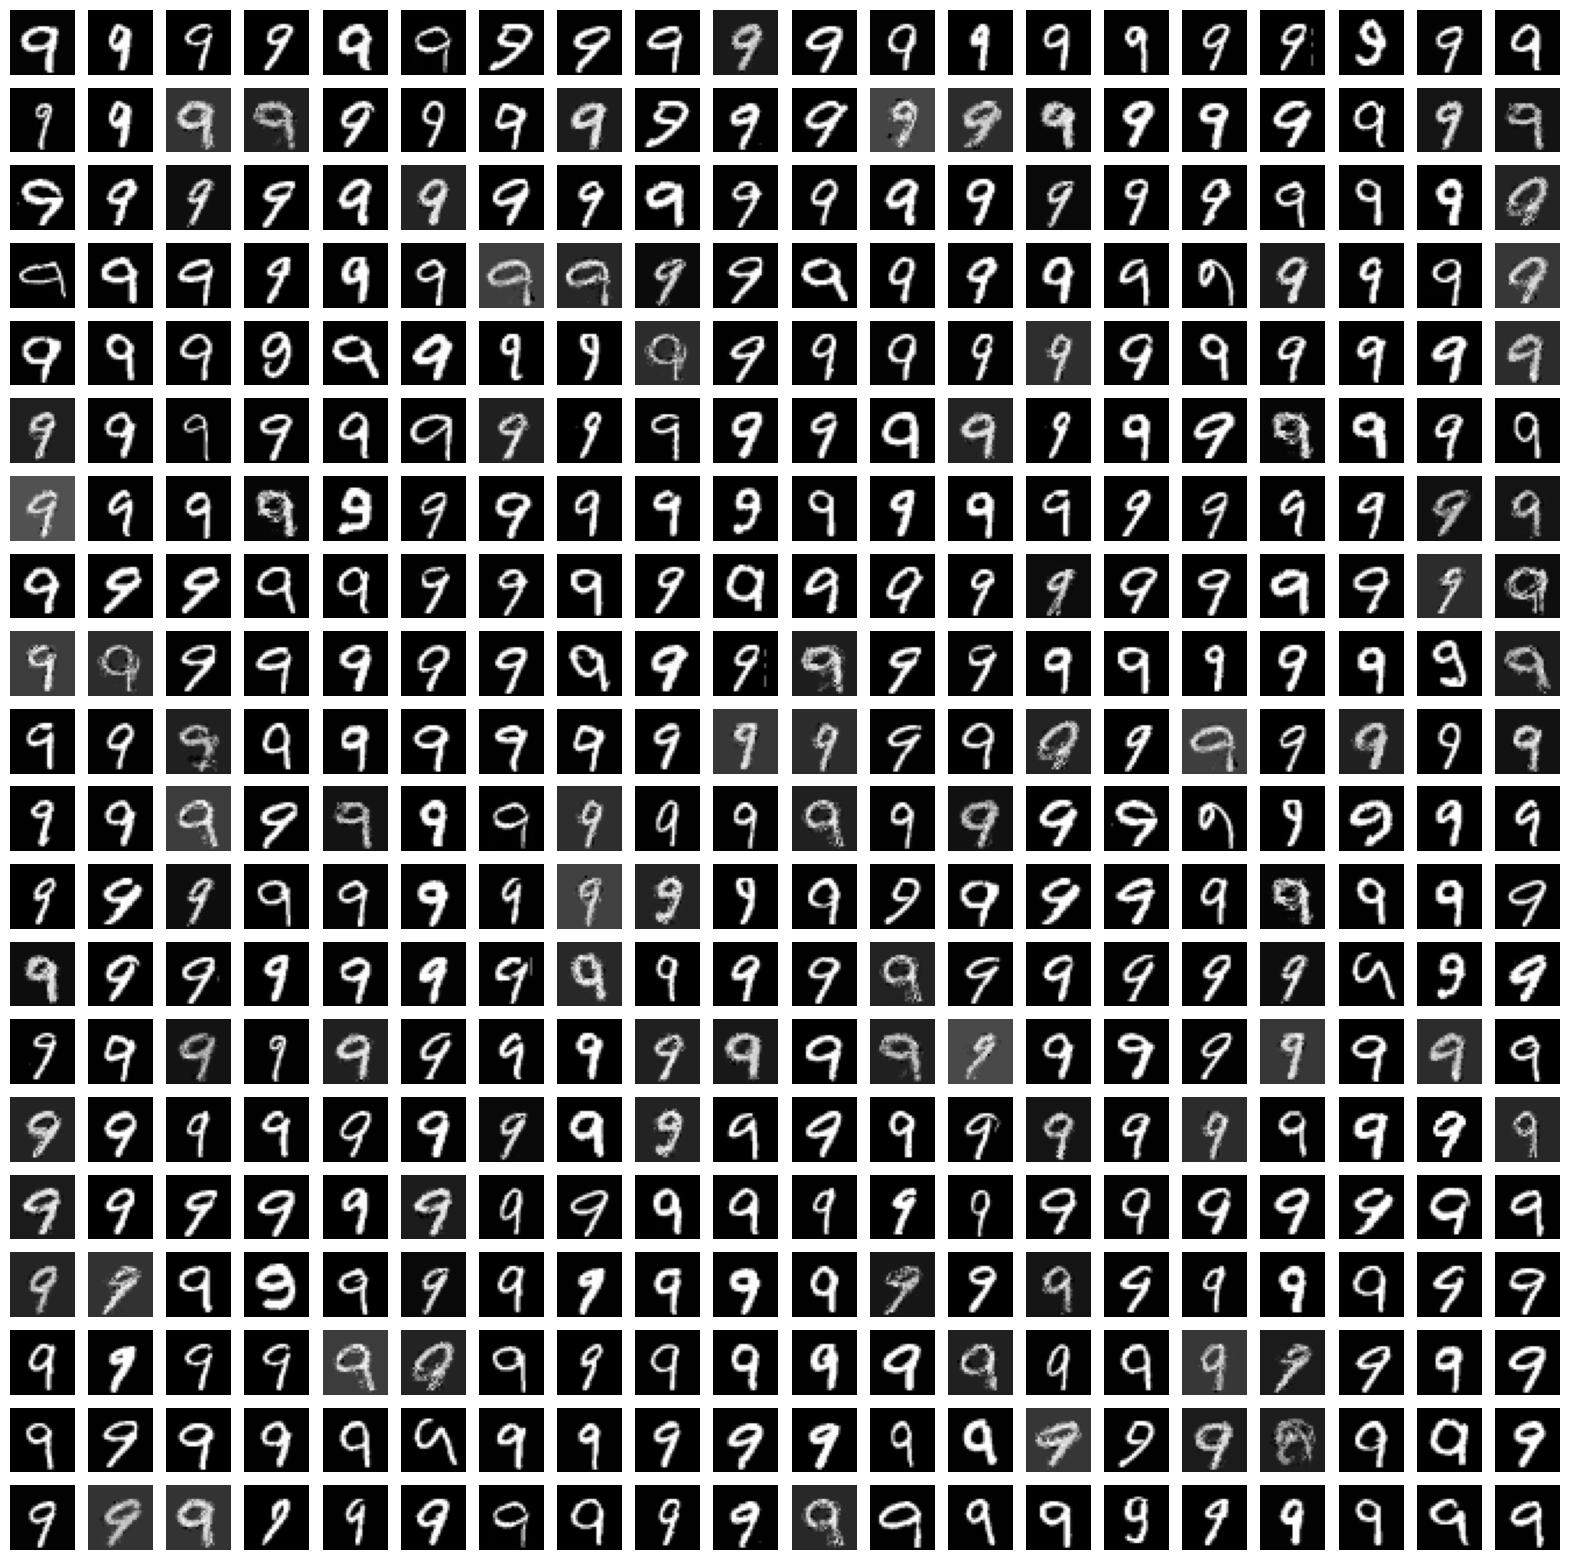

In [23]:
plot_generated_images(generated_images)